In [ ]:
!pip install --upgrade google-cloud-bigquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: google-cloud-bigquery
    Found existing installation: google-cloud-bigquery 3.44.0
    Uninstalling google-cloud-bigquery-3.44.0:
      Successfully uninstalled google-cloud-bigquery-3.44.0


In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
auth.authenticate_user()

In [ ]:
client = bigquery.Client(project = "data-analytics-mate")

In [ ]:
query = """
SELECT s.date,
sp.ga_session_id,
sp.continent,
sp.country,
sp.device,
sp.browser,
sp.mobile_model_name,
sp.operating_system,
sp.language,
sp.channel,
sp.medium AS utm_medium,
sp.name AS channel_ad_info,
a.id AS account_id,
a.is_verified,
a.is_unsubscribed,
o.ga_session_id AS order_id,
p.category,
p.name AS product_name,
p.price,
p.short_description
FROM `DA.session` as s
LEFT JOIN `DA.session_params` as sp
ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `DA.account_session` as acs
ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `DA.account` as a
ON acs.account_id = a.id
LEFT JOIN `DA.order` AS o
ON s.ga_session_id = o.ga_session_id
LEFT JOIN `DA.product` AS p
ON o.item_id = p.item_id
"""
df = pd.read_gbq(query, project_id = "data-analytics-mate")

/tmp/ipykernel_634/2179207056.py:34: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(query, project_id = "data-analytics-mate")


To obtain data for analysis, we had to connect to Google BigQuery and retrieve the necessary dataset using an SQL query. A data frame has been created based on this dataset, which will be used for analysis.

#Dataframe description

In [ ]:
print(df.head())

         date  ga_session_id continent         country   device browser  \
0  2020-11-01     5760483956  Americas   United States  desktop  Chrome   
1  2020-11-01     7115337200    Europe  United Kingdom  desktop  Chrome   
2  2020-11-01     3978035233    Europe          Norway   mobile  Chrome   
3  2020-11-01     9648986282    Africa         Nigeria   mobile  Chrome   
4  2020-11-01     4393441533      Asia           China  desktop  Chrome   

  mobile_model_name operating_system language         channel utm_medium  \
0            Safari        Macintosh       zh     Paid Search    <Other>   
1            Chrome              Web    en-us  Organic Search    organic   
2           <Other>              Web       zh          Direct     (none)   
3           <Other>          Android    es-es          Direct     (none)   
4            Chrome          Windows    en-us          Direct     (none)   

  channel_ad_info  account_id  is_verified  is_unsubscribed    order_id  \
0         <Other>

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   channel            349545 non-null  object 
 10  utm_medium         349545 non-null  object 
 11  channel_ad_info    349545 non-null  object 
 12  account_id         27945 non-null   Int64  
 13  is_verified        27945 non-null   Int64  
 14  is_unsubscribed    27945 non-null   Int64  
 15  order_id           33538 non-null   Int64  
 16  ca

In [ ]:
print(df.describe())

           ga_session_id     account_id  is_verified  is_unsubscribed  \
count           349545.0        27945.0      27945.0          27945.0   
mean   4992250296.631739  659005.065557      0.71698          0.16944   
std    2887450949.537772   13216.529465     0.450474         0.375147   
min               1205.0       636133.0          0.0              0.0   
25%         2493646855.0       647576.0          0.0              0.0   
50%         4988476074.0       658952.0          1.0              0.0   
75%         7491286508.0       670414.0          1.0              0.0   
max         9999997129.0       681962.0          1.0              1.0   

                order_id         price  
count            33538.0  33538.000000  
mean   4964900683.146312    953.298679  
std    2884281407.544156   1317.001775  
min             330355.0      3.000000  
25%         2476893918.0    170.000000  
50%         4961245290.0    445.000000  
75%        7442296865.75   1195.000000  
max         99

In [ ]:
print(df["date"].min())
print(df["date"].max())
print(df["date"].max()-df["date"].min())

2020-11-01
2021-01-31
91 days, 0:00:00


In [ ]:
df[df["price"].notna()]["date"].max()

datetime.date(2021, 1, 27)

In [ ]:
print(df.isnull().sum())

date                      0
ga_session_id             0
continent                 0
country                   0
device                    0
browser                   0
mobile_model_name         0
operating_system          0
language             114266
channel                   0
utm_medium                0
channel_ad_info           0
account_id           321600
is_verified          321600
is_unsubscribed      321600
order_id             316007
category             316007
product_name         316007
price                316007
short_description    316007
dtype: int64


In total, the dataframe contains 19 columns, including:

1 column with a date (date);

1 column with a float (price);

2 columns with Boolean values (is_verified, is_unsubscribed);

16 categorical columns (ga_session_id, continent, country, device, browser, mobile_model_name, operating_system, language, channel, utm_medium, channel_ad_info, account_id, item_id, category, product_name, short_description). Although ga_session_id, account_id, and order_id technically appear to be numeric, they are identifiers that can also be used to aggregate data.

We have 349,545 unique sessions.

The data covers the period from November 1, 2020, to January 31, 2021. This spans 91 days.

The dataset contains columns with missing values:

language (session language not specified);

account_id, is_verified, is_unsubscribed—empty values in the account data columns. We include these sessions even if the user did not register;

category, product_name, price, short_description—empty values in these columns are caused by sessions during which no order was placed;

there were no sales on the last days from January 28 through January 31, so this should be taken into account when analyzing by date.

#Online store Sales Analytics

In [ ]:
top_continent_sales = df.groupby(["continent"])["price"].sum().sort_values(ascending = False).head(3)
top_continent_orders = df.groupby(["continent"])["order_id"].count().sort_values(ascending = False).head(3)
top_countries_sales = df.groupby(["country"])["price"].sum().sort_values(ascending = False).head(5)
top_countries_orders = df.groupby(["country"])["order_id"].count().sort_values(ascending = False).head(5)

In [ ]:
print(top_continent_sales)
print(top_continent_orders)
print(top_countries_sales)
print(top_countries_orders)

continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: price, dtype: float64
continent
Americas    18553
Asia         7950
Europe       6261
Name: order_id, dtype: Int64
country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: price, dtype: float64
country
United States     14673
India              3029
Canada             2560
United Kingdom     1029
France              678
Name: order_id, dtype: Int64


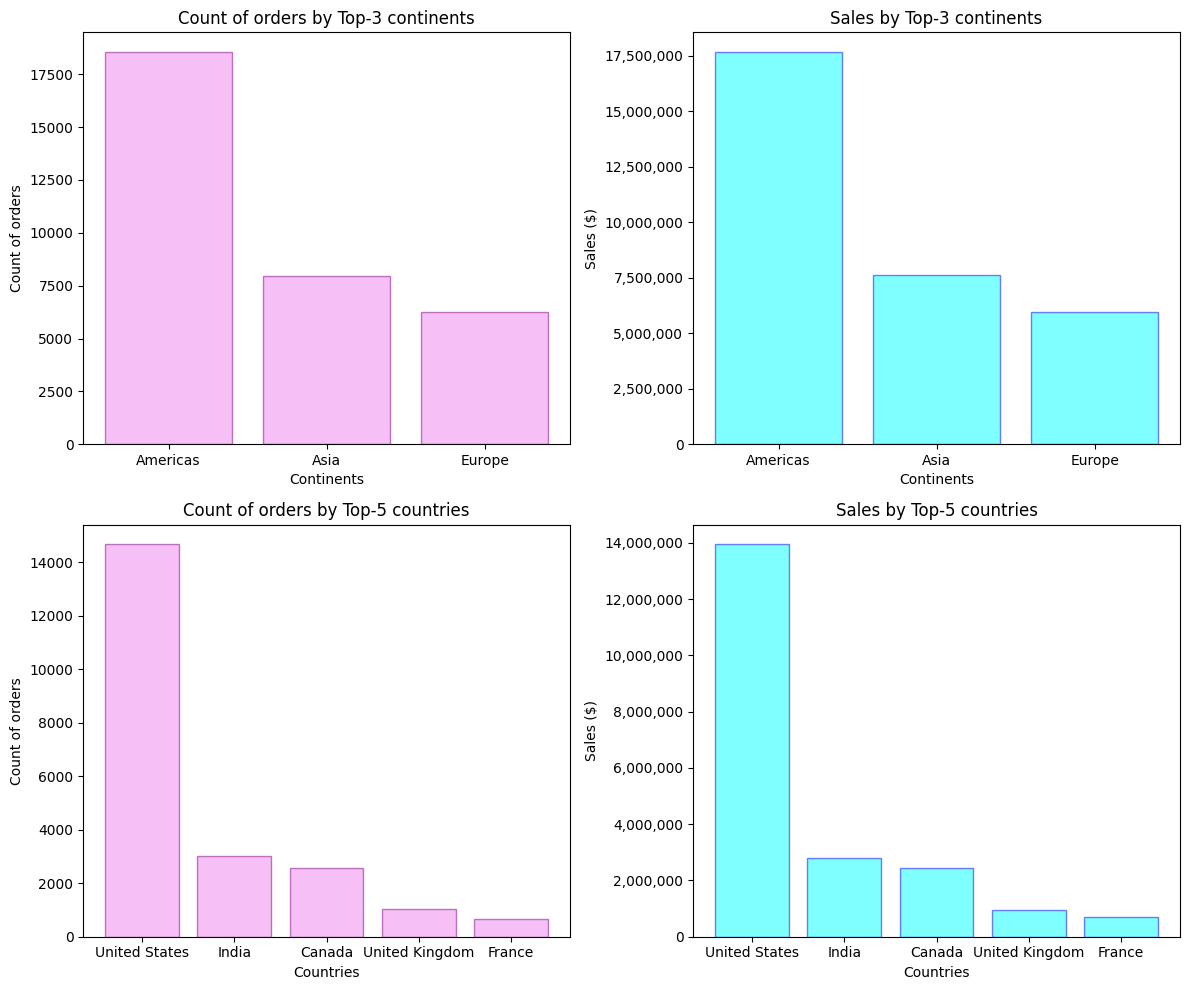

In [ ]:
fig,ax = plt.subplots (2, 2, figsize = (12,10))
sns.barplot()
ax[0,0].bar(top_continent_orders.index, top_continent_orders.values, color = "violet", edgecolor = "purple", alpha = 0.5)
ax[0,0].set_title("Count of orders by Top-3 continents")
ax[0,0].set_xlabel("Continents")
ax[0,0].set_ylabel("Count of orders")

ax[0,1].bar(top_continent_sales.index, top_continent_sales.values, color = "cyan", edgecolor = "blue", alpha = 0.5)
ax[0,1].set_title("Sales by Top-3 continents")
ax[0,1].set_xlabel("Continents")
ax[0,1].set_ylabel("Sales ($)")
ax[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))

ax[1,0].bar(top_countries_orders.index, top_countries_orders.values, color = "violet", edgecolor = "purple", alpha = 0.5)
ax[1,0].set_title("Count of orders by Top-5 countries")
ax[1,0].set_xlabel("Countries")
ax[1,0].set_ylabel("Count of orders")

ax[1,1].bar(top_countries_sales.index, top_countries_sales.values, color = "cyan", edgecolor = "blue", alpha = 0.5)
ax[1,1].set_title("Sales by Top-5 countries")
ax[1,1].set_xlabel("Countries")
ax[1,1].set_ylabel("Sales ($)")
ax[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.tight_layout()
plt.show()

The company was most successful on the following continents:
- Americas    $17,665,280.0 and 18,553 completed orders;

- Asia         $7,601,298.3 and 7,950 completed orders;

- Europe       $5,934,624.2 and 6,261 completed orders.


By country:
- United States     $13,943,553.9 and 14,673 completed orders;

- India              $2,809,762.0 and 3,029 completed orders;

- Canada             $2,437,921.0 and 2,560 completed orders;

- United Kingdom      $938,317.9 and 1,029 completed orders;

- France              $710,692.8 and 678 completed orders.

In [ ]:
top_category_sales = df.groupby(["category"])["price"].sum().sort_values(ascending = False).head(10)
print(top_category_sales)

category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: price, dtype: float64


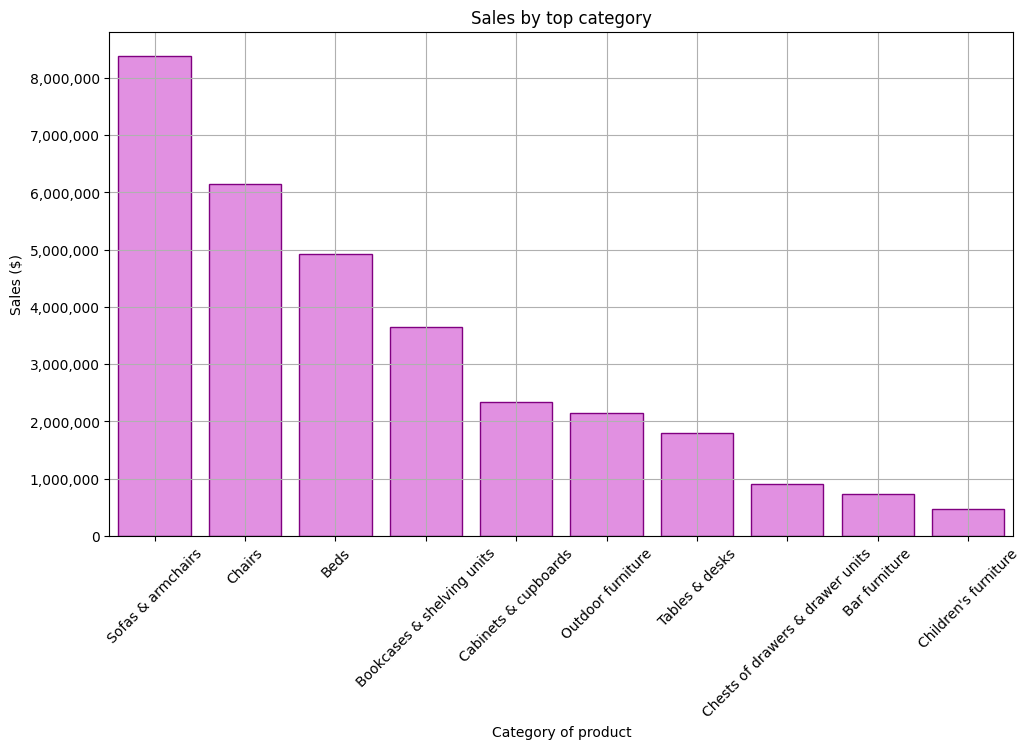

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(top_category_sales, color = "violet", edgecolor = "purple")
plt.title("Sales by top category")
plt.xlabel("Category of product")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.xticks(rotation = 45)
plt.grid(True)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.show()

The most popular categories in this store:
1. Sofas & armchairs                   $8,388,254.5

2. Chairs                              $6,147,748.8

3. Beds                                $4,919,725.0

4. Bookcases & shelving units          $3,640,818.1

5. Cabinets & cupboards                $2,336,499.5

6. Outdoor furniture                   $2,142,222.2

7. Tables & desks                      $1,790,307.5

8. Chests of drawers & drawer units     $906,562.5

9. Bar furniture                        $735,503.0

10. Children's furniture                 $467,697.0

In [ ]:
top_country = top_countries_sales.index[0]
top10_category_top_country = df[df["country"]==top_country].groupby(["category"])["price"].sum().sort_values(ascending = False).head(10)
print(top10_category_top_country)


category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.0
Children's furniture                 207575.0
Name: price, dtype: float64


If we look at product categories by the top-selling country, the overall trend remains the same.

In [ ]:
top_category_median_sales = df.groupby(["category"])["price"].median().sort_values(ascending = False).head(10)
print(top_category_median_sales)

category
Sofas & armchairs                       1176.0
Beds                                    1095.0
Sideboards, buffets & console tables     890.0
Cabinets & cupboards                     841.0
Room dividers                            495.0
Chests of drawers & drawer units         460.0
Bar furniture                            435.0
Chairs                                   395.0
Tables & desks                           376.0
Outdoor furniture                        356.0
Name: price, dtype: float64


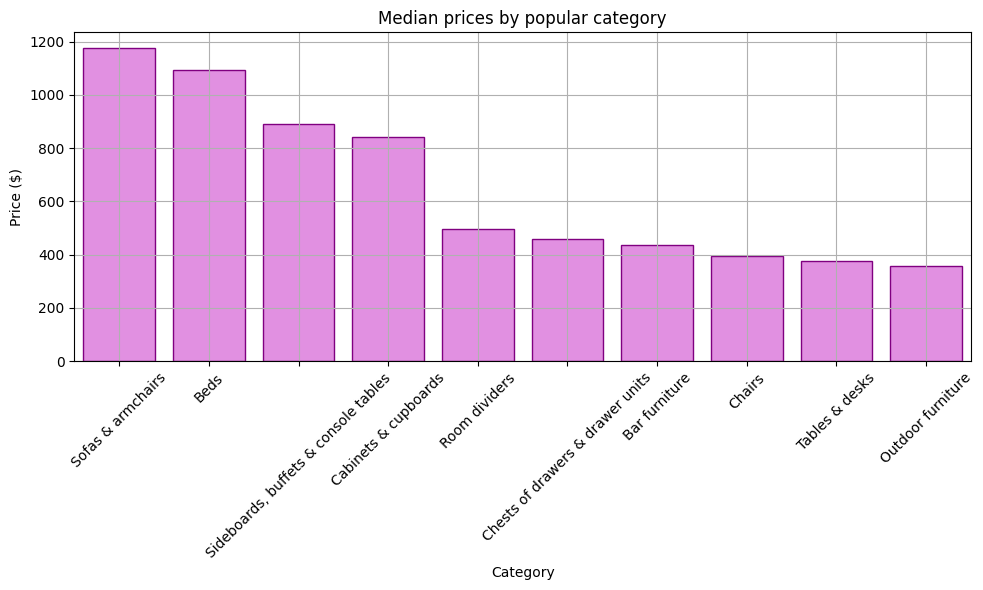

In [ ]:
plt.figure(figsize = (10,6))
sns.barplot(top_category_median_sales, color = "violet", edgecolor = "purple")
plt.title("Median prices by popular category")
plt.xlabel("Category")
plt.ylabel("Price ($)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.grid(True)
plt.show()

Median prices by category:
- Sofas & armchairs                       $1,176.0

- Beds                                    $1,095.0

- Sideboards, buffets & console tables     $890.0

- Cabinets & cupboards                     $841.0

- Room dividers                            $495.0

- Chests of drawers & drawer units         $460.0

- Bar furniture                            $435.0

- Chairs                                   $395.0

- Tables & desks                           $376.0

- Outdoor furniture                        $356.0

In [ ]:
device_sales = df.groupby(["device"])["price"].sum()/df["price"].sum()*100
print(device_sales)

device
desktop    59.002245
mobile     38.734924
tablet      2.262831
Name: price, dtype: float64


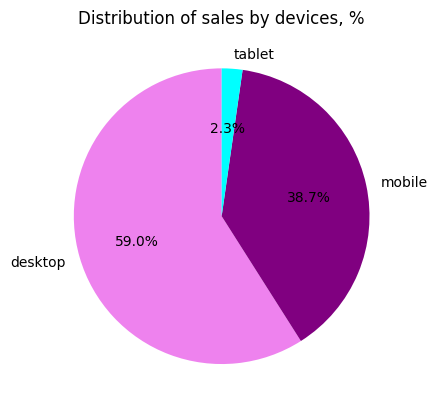

In [ ]:
plt.pie(device_sales, labels = device_sales.index, autopct='%1.1f%%',  startangle=90, colors = ["violet","purple", "cyan"])
plt.title("Distribution of sales by devices, %")
plt.grid()
plt.show()

In [ ]:
model_sales = df.groupby(["mobile_model_name"])["price"].sum()/df["price"].sum()*100
model_sales = model_sales.sort_values(ascending = False)
print(model_sales)

mobile_model_name
Chrome        27.835602
<Other>       20.440966
Safari        20.302504
iPhone        20.082667
ChromeBook     5.725241
Edge           2.180746
iPad           1.403910
Firefox        1.316998
Pixel 4 XL     0.369976
Pixel 3        0.341390
Name: price, dtype: float64


In terms of devices, users who placed orders via the desktop version accounted for the largest share of sales—59 percent—followed by mobile device users at about 39 percent. Approximately 2 percent of sales were made via tablets.

Looking more closely at device models, it’s noticeable that about 20% were not identified. The most popular models are Chrome, Safari, and iPhone.

In [ ]:
channel_sales = df.groupby(["channel"])["price"].sum()/df["price"].sum()*100
channel_sales = channel_sales.sort_values(ascending = False)
print(channel_sales)

channel
Organic Search    35.760189
Paid Search       26.620546
Direct            23.442345
Social Search      7.919827
Undefined          6.257093
Name: price, dtype: float64


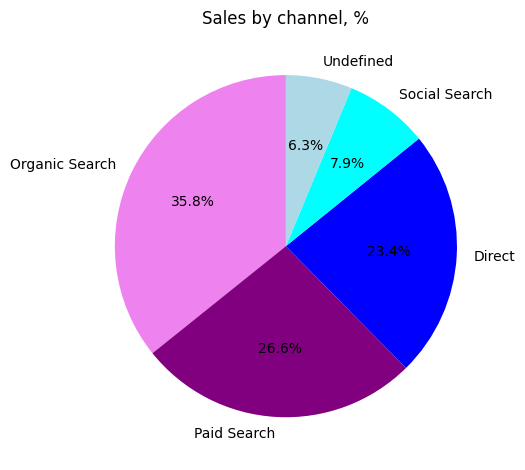

In [ ]:
plt.pie(channel_sales, labels = channel_sales.index, autopct='%1.1f%%',  startangle=90, colors = ["violet","purple", "blue", "cyan", "lightblue"])
plt.title("Sales by channel, %")
plt.tight_layout()
plt.show()

In terms of traffic sources, revenue is generated by the following channels:
- Organic Search 35.76%;
- Paid Search 26.62%;
- Direct 23.44%;
- Social Search 7.92%.

An additional 6.25% is undenfined.

In [ ]:
os_sales = df.groupby(["operating_system"])["price"].sum()/df["price"].sum()*100
os_sales = os_sales.sort_values(ascending = False)
print(os_sales)

operating_system
Web          57.694419
Windows      11.901104
iOS          11.270361
Android       8.726412
Macintosh     7.834944
<Other>       2.572760
Name: price, dtype: float64


By operating system, the largest percentage of orders was placed via the Web—57.69%.

2.57% of the operating systems were unable to identify.

In [ ]:
language_sales = df.groupby(["language"])["price"].sum()/df["price"].sum()*100
language_sales = language_sales.sort_values(ascending = False)
print(language_sales)

language
en-us    46.027755
en-gb     6.822634
zh        3.293662
en        3.113804
en-ca     2.436066
fr        1.811051
es-es     1.609463
ko        0.933727
de        0.804113
Name: price, dtype: float64


The most popular language for active sessions is English, with regional variations. Chinese is also common (zh - 3.29%), although China does not appear on the list of countries with the highest total revenue.

In [ ]:
verified_users = df[df["is_verified"] == 1]["account_id"].nunique()
users_registration = df["account_id"].nunique()
percent_users_registration =verified_users/users_registration*100
print(f"{percent_users_registration: .2f}% of users verified their email addresses.")

 71.70% of users verified their email addresses.


In [ ]:
unsubscribed_users = df[df["is_unsubscribed"] == 1]["account_id"].nunique()
total_users = df["account_id"].nunique()
percent_unsubscribed = unsubscribed_users/total_users*100
print(f"{percent_unsubscribed: .2f}% users unsubscribed from the email newsletter")

 16.94% users unsubscribed from the email newsletter


In [ ]:
sales_un_subscription = df.groupby(["is_unsubscribed"])["price"].agg(["mean", "median", "count"])
print(sales_un_subscription)


                       mean  median  count
is_unsubscribed                           
0                921.506812   395.0   2334
1                965.820134   450.0    447


The analysis shows that customers who have unsubscribed from the newsletter continue to make purchases and, on average, even generate slightly more revenue. The average differs significantly from the median due to variations in product prices. If we look solely at the median, the average order value for a customer who is subscribed to the newsletter is \$395, while for an unsubscribed customer it is \$450.

In [ ]:
top_country_accounts = df.groupby(["country"])["account_id"].nunique().sort_values(ascending = False).head(5)
print(top_country_accounts)

country
United States     12384
India              2687
Canada             2067
United Kingdom      859
France              553
Name: account_id, dtype: int64


Countries with the most registered users:
- United States     12,384 accounts;
- India              2,687 accounts;
- Canada             2,067 accounts;
- United Kingdom      859 accounts;
- France              553 accounts.

#Sales Dynamics Analysis

In [ ]:
from datetime import date


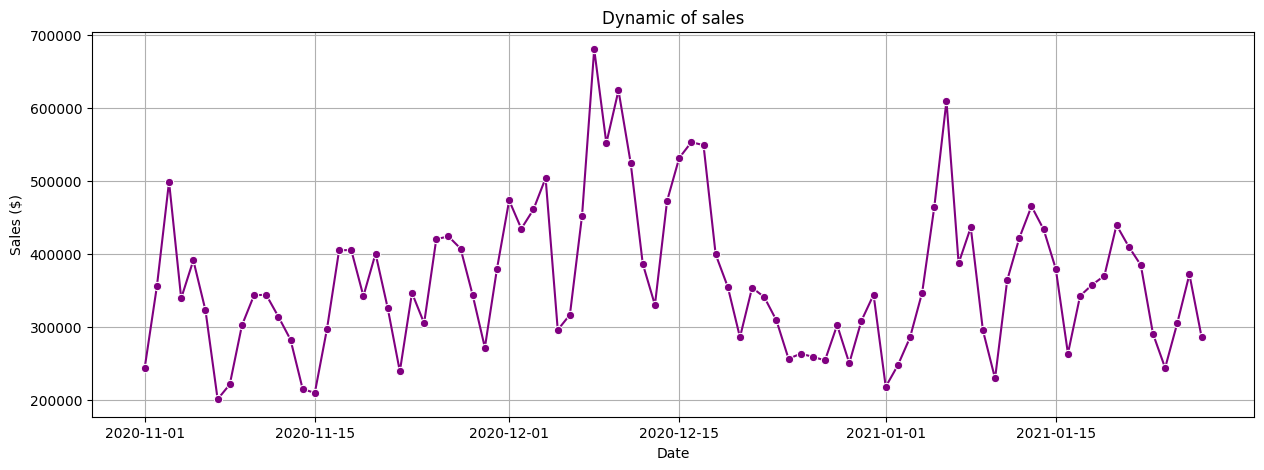

In [ ]:
sales_dynamic = df[df["price"].notna()].groupby(["date"])["price"].sum()
plt.figure(figsize=(15,5))
sns.lineplot(sales_dynamic, marker = "o", color = "purple")
plt.title("Dynamic of sales")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.show()

In [ ]:
sales_dynamic.sort_values(ascending = False).head(5)

,price
date,
2020-12-08,680509.5
2020-12-10,624104.6
2021-01-06,609763.8
2020-12-16,553134.9
2020-12-09,551811.6


The visualization shows a certain seasonality in sales. For example, the first half of December has exceptionally strong sales, with peak values:
- 2020-12-08 - 680,509.5 ($);

- December 9, 2020 - 551,811.6 ($);

- December 10, 2020 - 624,104.6 ($);

- December 16, 2020 - 553,134.9 ($).

Sales dropped sharply in the second half of the month. It is possible that this was due to the Christmas holidays, as sales rose again in the first half of January and reached a peak:

- January 6, 2021 -    609,763.8 ($).

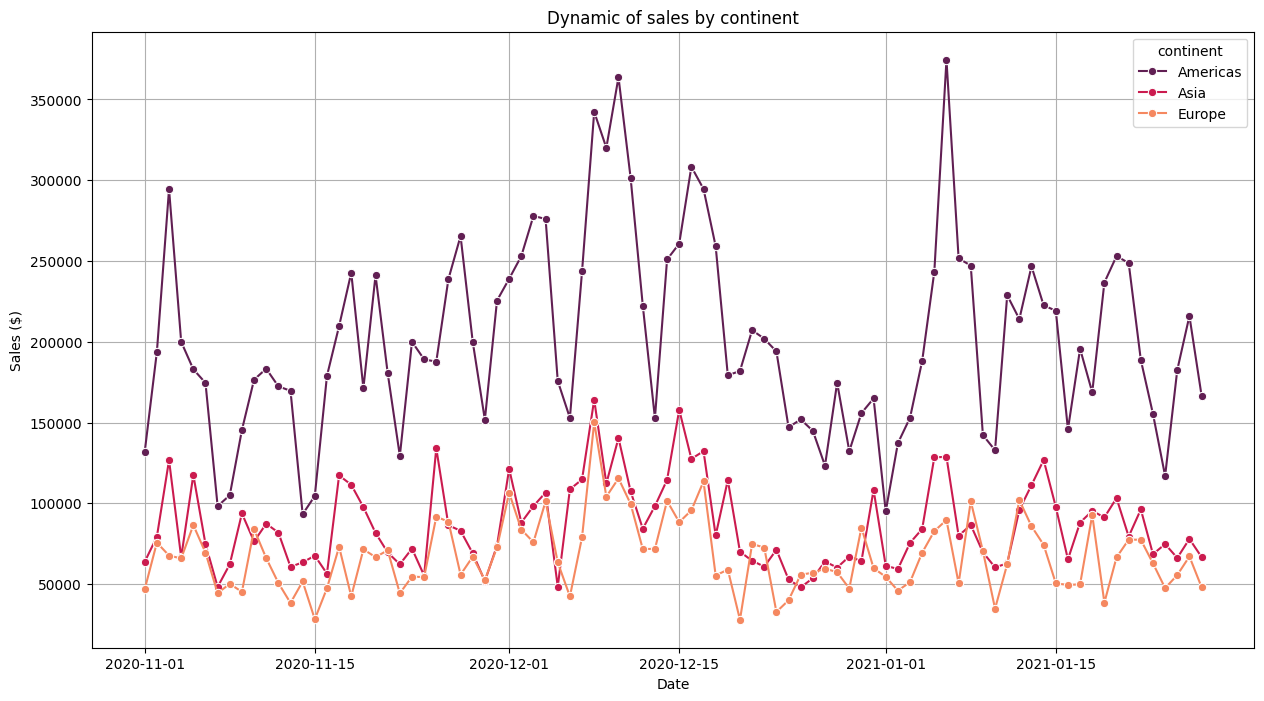

In [ ]:
continents_dynamic = df[df["continent"].isin(["Americas","Asia", "Europe"]) & df["price"].notna()].groupby(["date","continent"])["price"].sum().reset_index()
continents_dynamic = continents_dynamic.sort_values("price", ascending=False)
plt.figure(figsize=(15,8))
sns.lineplot(data=continents_dynamic, x="date", y="price", hue="continent", marker="o", palette = "rocket")
plt.title("Dynamic of sales by continent")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.show()

The graph shows that seasonal fluctuations persist across continents. Since total sales in the Americas are significantly higher than in other continents, these fluctuations become even more pronounced.

In [ ]:
channel_dynamic = df[df["price"].notna()].groupby(["date","channel"])["price"].sum().reset_index()
channel_dynamic = pd.DataFrame(channel_dynamic)

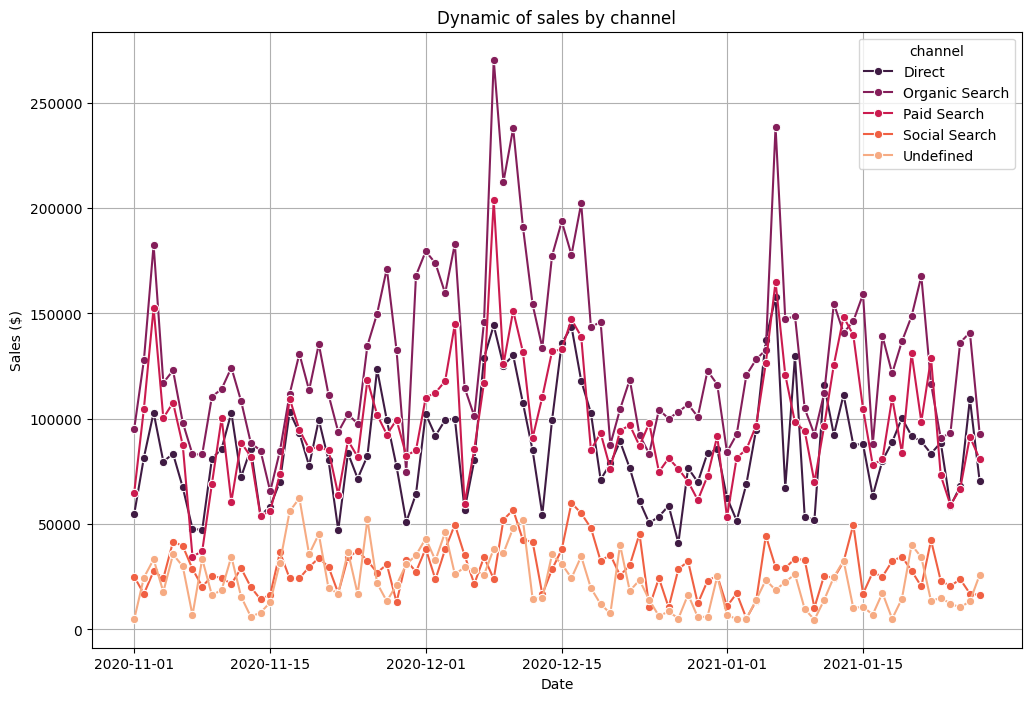

In [ ]:
plt.figure(figsize = (12, 8))
sns.lineplot(channel_dynamic, x = "date", y = "price", hue = "channel", palette = "rocket", marker = "o")
plt.title("Dynamic of sales by channel")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.show()

It is evident that seasonal fluctuations are observed among the following channels:
- Organic Search;
- Paid Search;
- Direct.

No sharp seasonal fluctuations are observed among Social Search and Undefined.

Since the largest surge in sales came specifically from organic and paid search sources, it is highly likely that this was due to pre-holiday excitement.

In [ ]:
device_dynamic = df[df["price"].notna()].groupby(["date", "device"])["price"].sum().reset_index()
device_dynamic = pd.DataFrame(device_dynamic)

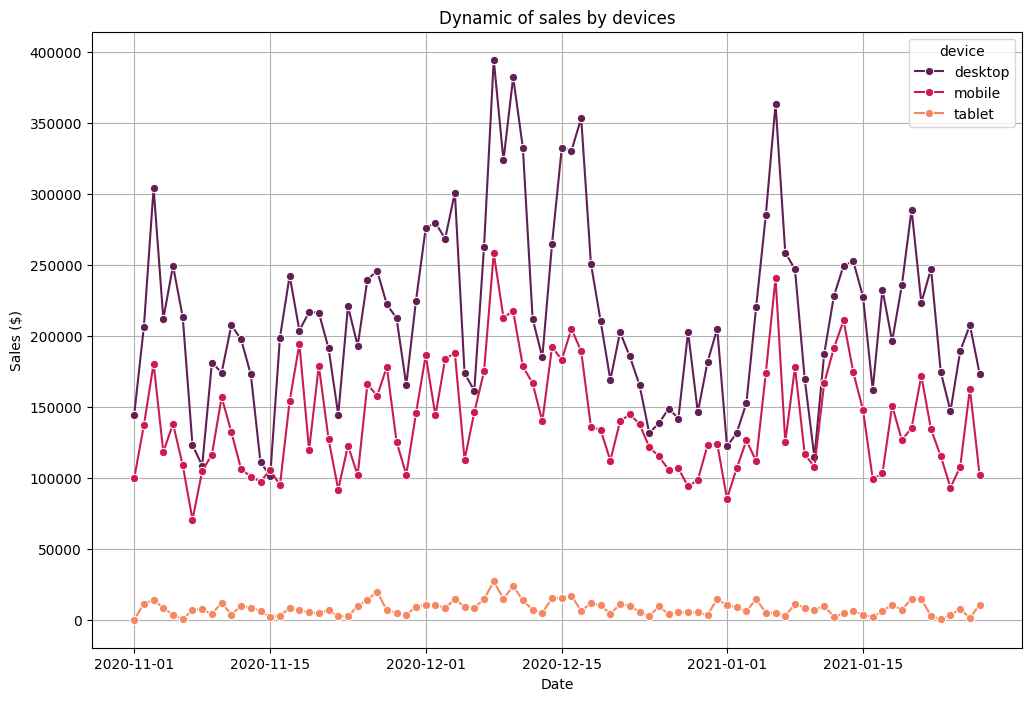

In [ ]:
plt.figure(figsize=(12, 8))
sns.lineplot(device_dynamic, x = "date", y = "price", hue = "device", marker = "o", palette = "rocket")
plt.title("Dynamic of sales by devices")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.show()

This graph shows that daily fluctuations occurred almost simultaneously across all devices. It is evident that the magnitude of the fluctuations is directly proportional to the total sales across the devices.

#Pivot Tables

####Session counts by traffic channel and device type.

In [ ]:
session_by_channel_device = pd.pivot_table(df, values = "ga_session_id", index = ["channel", "device"], aggfunc="count").dropna()
print(session_by_channel_device)

                        ga_session_id
channel        device                
Direct         desktop          47825
               mobile           31745
               tablet            1812
Organic Search desktop          72622
               mobile           49014
               tablet            2789
Paid Search    desktop          55167
               mobile           37034
               tablet            2140
Social Search  desktop          16288
               mobile           10988
               tablet             638
Undefined      desktop          12527
               mobile            8486
               tablet             470


####Number of users who have verified their accounts and users who have unsubscribed from the newsletter, broken down by traffic channels and device types.

In [ ]:
verified = df[df["is_verified"] == 1].pivot_table(values="account_id", index=["channel", "device"],aggfunc="nunique")
unsubscribed = df[df["is_unsubscribed"] == 1].pivot_table(values="account_id", index=["channel", "device"],aggfunc="nunique")
accounts_by_channel_device = pd.DataFrame({"verified": verified["account_id"],"unsubscribed": unsubscribed["account_id"]})
print(accounts_by_channel_device)

                        verified  unsubscribed
channel        device                         
Direct         desktop      2816           661
               mobile       1808           424
               tablet        108            23
Organic Search desktop      4170          1007
               mobile       2867           692
               tablet        159            41
Paid Search    desktop      3099           689
               mobile       2129           524
               tablet        122            27
Social Search  desktop       904           231
               mobile        591           119
               tablet         38             9
Undefined      desktop       746           187
               mobile        459            97
               tablet         20             4


####Total sales by the most popular product categories, broken down by the countries with the highest sales figures.

In [ ]:
filtered_country_category = df[df["country"].isin(top_countries_sales.index) & df["category"].isin(top_category_sales.index)]
table_top_country_category = pd.pivot_table(filtered_country_category, values = "price", index = ["country", "category"], aggfunc = "sum").sort_values(by=["country", "price"], ascending = [False, False])
print(table_top_country_category)

                                                     price
country        category                                   
United States  Sofas & armchairs                 3707144.5
               Chairs                            2619773.8
               Beds                              2213058.0
               Bookcases & shelving units        1567606.9
               Cabinets & cupboards               994545.5
               Outdoor furniture                  929245.2
               Tables & desks                     777865.0
               Chests of drawers & drawer units   382388.0
               Bar furniture                      330805.0
               Children's furniture               207575.0
United Kingdom Sofas & armchairs                  234812.0
               Chairs                             188519.4
               Beds                               133816.0
               Bookcases & shelving units         113987.6
               Cabinets & cupboards                71684

#Statistical Analysis of Correlations

In [ ]:
date_sessions = df.groupby(["date"])["ga_session_id"].count().reset_index()
date_sales = df[df["price"].notna()].groupby(["date"])["price"].sum().reset_index()
date_sessions_sales = pd.DataFrame({"date": date_sessions["date"], "sessions_cnt": date_sessions["ga_session_id"], "sales": date_sales["price"]}).dropna()
print(date_sessions_sales)

          date  sessions_cnt     sales
0   2020-11-01          2576  244292.5
1   2020-11-02          3599  355506.8
2   2020-11-03          5173  498979.6
3   2020-11-04          4184  339187.1
4   2020-11-05          3743  391276.6
..         ...           ...       ...
83  2021-01-23          3067  290605.5
84  2021-01-24          2893  243818.4
85  2021-01-25          3760  305089.3
86  2021-01-26          3970  372057.3
87  2021-01-27          4435  286340.7

[88 rows x 3 columns]


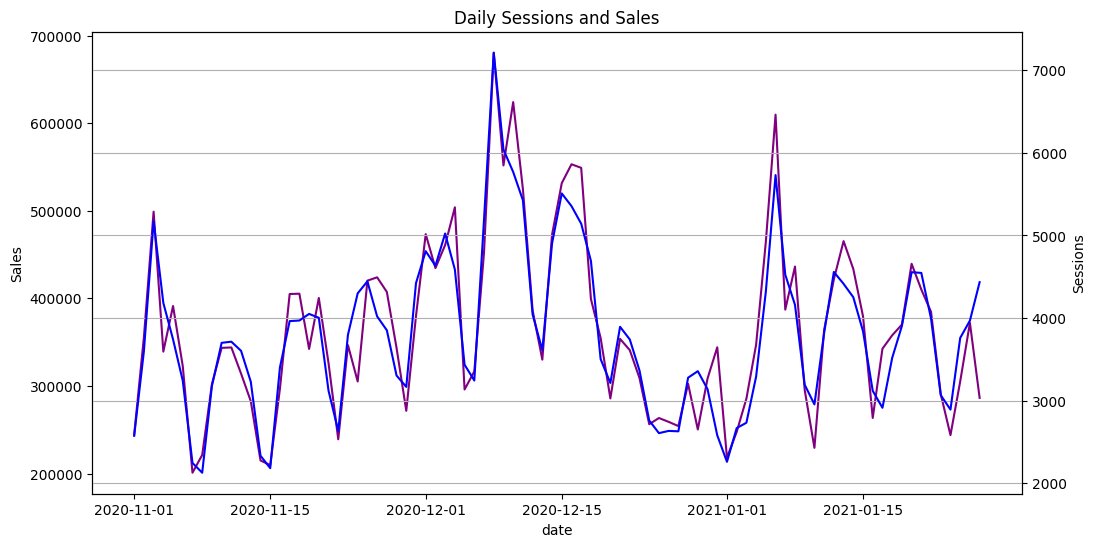

In [ ]:
fig, ax1 = plt.subplots(figsize = (12,6))
sns.lineplot(date_sessions_sales, x = "date", y = "sales", ax=ax1, color = "purple")
ax1.set_ylabel("Sales", color = "black")
ax2 = ax1.twinx()
sns.lineplot(date_sessions_sales, x = "date", y = "sessions_cnt", ax=ax2, color = "blue")
ax2.set_ylabel("Sessions", color = "black")
plt.title("Daily Sessions and Sales")
plt.grid(True)
plt.show()

In [ ]:
from scipy.stats import normaltest
_, p_value_normaltest_date_sales = normaltest(date_sessions_sales["sales"])
_, p_value_normaltest_date_sessions = normaltest(date_sessions_sales["sessions_cnt"])
print(p_value_normaltest_date_sales)
print(p_value_normaltest_date_sessions)

0.007155898618108501
0.014530886606437964


The test for normality of distribution showed that daily sales and the number of sessions are not normally distributed, since in both cases the p-value is less than 0.05.
The Spearman method is more suitable for determining the correlation coefficient.

In [ ]:
from scipy.stats import spearmanr
spearman_corr_sales_sessions = date_sessions_sales["sales"].corr(date_sessions_sales["sessions_cnt"], method = "spearman")
print(f"Test for statistical significance: {spearmanr(date_sessions_sales["sales"],date_sessions_sales["sessions_cnt"])}")
print(f"Correlation coefficient: {spearman_corr_sales_sessions}")

Test for statistical significance: SignificanceResult(statistic=np.float64(0.904283047444613), pvalue=np.float64(1.5381769633064087e-33))
Correlation coefficient: 0.904283047444613


Spearman's correlation coefficient, which is 0.90 and is statistically significant, showed a strong positive correlation between the number of sessions and sales for each date.

In [ ]:
continent_sales = df[df["continent"].isin(top_continent_sales.index)][["date","continent","price"]]
continent_sales = continent_sales.dropna()
date_continent_sales = continent_sales.groupby(["date", "continent"])["price"].sum().reset_index()
print(date_continent_sales)

           date continent     price
0    2020-11-01  Americas  132002.5
1    2020-11-01      Asia   63823.0
2    2020-11-01    Europe   46908.0
3    2020-11-02  Americas  193861.0
4    2020-11-02      Asia   79370.0
..          ...       ...       ...
259  2021-01-26      Asia   77995.2
260  2021-01-26    Europe   67143.1
261  2021-01-27  Americas  166735.5
262  2021-01-27      Asia   66783.1
263  2021-01-27    Europe   48156.1

[264 rows x 3 columns]


In [ ]:
date_europe_sales = continent_sales[continent_sales["continent"] == "Europe"][["date","price"]]
date_asia_sales = continent_sales[continent_sales["continent"] == "Asia"][["date","price"]]
date_americas_sales = continent_sales[continent_sales["continent"] == "Americas"][["date","price"]]
date_europe_sales = date_europe_sales.groupby(["date"])["price"].sum().reset_index()
date_asia_sales = date_asia_sales.groupby(["date"])["price"].sum().reset_index()
date_americas_sales = date_americas_sales.groupby(["date"])["price"].sum().reset_index()

In [ ]:
_, p_value_normaltest_europe = normaltest(date_europe_sales["price"])
print(f"P-value for distribution of sales in Europe by date: {p_value_normaltest_europe}")

_, p_value_normaltest_asia = normaltest(date_asia_sales["price"])
print(f"P-value for distribution of sales in Asia by date: {p_value_normaltest_asia}")

_, p_value_normaltest_americas = normaltest(date_americas_sales["price"])
print(f"P-value for distribution of sales in Americas by date: {p_value_normaltest_americas}")

P-value for distribution of sales in Europe by date: 0.002457815575210439
P-value for distribution of sales in Asia by date: 0.017908999071036248
P-value for distribution of sales in Americas by date: 0.05795014942671144


A test to determine whether the distribution is normal showed that sales by date, broken down by continent, are not normally distributed in Europe and Asia. In both cases, the p-value is less than 0.05. Sales by date in the Americas are normally distributed.

In [ ]:
from scipy import stats

In [ ]:
continent_date = date_europe_sales.merge(date_asia_sales, on = "date", how = "outer")\
.merge(date_americas_sales, on = "date", how = "outer")
continent_date = continent_date.rename(columns={
                                       "price": "europe",
                                       "price_x": "asia",
                                       "price_y": "americas"})
continent_date[["europe", "asia", "americas"]].corr()

,europe,asia,americas
europe,1.000000,0.669527,0.692273
asia,0.669527,1.000000,0.667786
americas,0.692273,0.667786,1.000000


In [ ]:
continent_date[["europe", "asia", "americas"]].corr(method = "spearman")

,europe,asia,americas
europe,1.000000,0.625885,0.668539
asia,0.625885,1.000000,0.608221
americas,0.668539,0.608221,1.000000


In [ ]:
f_stat_continent_eu_a, p_value_continent_eu_a = stats.spearmanr(continent_date["europe"], continent_date["asia"])
print(f_stat_continent_eu_a, p_value_continent_eu_a)

0.6258849635447854 7.009052955139405e-11


In [ ]:
f_stat_continent_eu_amer, p_value_continent_eu_amer = stats.spearmanr(continent_date["europe"], continent_date["americas"])
print(f_stat_continent_eu_amer, p_value_continent_eu_amer)

0.6685393258426968 1.1001059722381636e-12


In [ ]:
f_stat_continent_asia_americas, p_value_continent_asia_americas = stats.spearmanr(continent_date["asia"], continent_date["americas"])
print(f_stat_continent_asia_americas, p_value_continent_asia_americas)

0.6082209150787222 3.2731384105062476e-10


After analyzing sales for each date by continent, a statistically significant, moderate positive correlation was found.

In [ ]:
country_df = df[df["country"].isin(top_countries_sales.index)][["date", "country", "price"]].dropna()
country_date_sales = country_df.groupby(["date", "country"])["price"].sum().reset_index()
country_date_sales.head(10)

,date,country,price
0,2020-11-01,Canada,10689.0
1,2020-11-01,France,4403.0
2,2020-11-01,India,18233.0
3,2020-11-01,United Kingdom,19433.0
4,2020-11-01,United States,115244.5
5,2020-11-02,Canada,32977.0
6,2020-11-02,France,5214.0
7,2020-11-02,India,24811.0
8,2020-11-02,United Kingdom,14498.0
9,2020-11-02,United States,145356.0


In [ ]:
date_us_sales = country_date_sales[country_date_sales["country"] == "United States"][["date", "price"]]
date_uk_sales = country_date_sales[country_date_sales["country"] == "United Kingdom"][["date", "price"]]
date_canada_sales = country_date_sales[country_date_sales["country"] == "Canada"][["date", "price"]]
date_france_sales = country_date_sales[country_date_sales["country"] == "France"][["date", "price"]]
date_india_sales = country_date_sales[country_date_sales["country"] == "India"][["date", "price"]]

In [ ]:
_, p_value_normaltest_us = normaltest(date_us_sales["price"])
print(f"P-value distribution of sales in United States: {p_value_normaltest_us}")

_, p_value_normaltest_uk = normaltest(date_uk_sales["price"])
print(f"P-value distribution of sales in United Kingdom: {p_value_normaltest_uk}")

_, p_value_normaltest_canada = normaltest(date_canada_sales["price"])
print(f"P-value distribution of sales in Canada: {p_value_normaltest_canada}")

_, p_value_normaltest_france = normaltest(date_france_sales["price"])
print(f"P-value distribution of sales in France: {p_value_normaltest_france}")

_, p_value_normaltest_india = normaltest(date_france_sales["price"])
print(f"P-value distribution of sales in India: {p_value_normaltest_india}")


P-value distribution of sales in United States: 0.04059457439870258
P-value distribution of sales in United Kingdom: 0.007103535048367455
P-value distribution of sales in Canada: 0.08678080987647548
P-value distribution of sales in France: 4.896891759465292e-07
P-value distribution of sales in India: 4.896891759465292e-07


A test for normality of distribution showed that sales by date across the top 5 countries are not normally distributed in the United Kingdom, France, India, and the United States because the p-value is less than 0.05. Sales by date in Canada are normally distributed.

In [ ]:
f_stat_us_canada_sales, p_value_us_canada_sales = stats.spearmanr(date_us_sales["price"], date_canada_sales["price"])
print(f"Correlation between sales by date in Canada and United States: {f_stat_us_canada_sales: .2f}. P-value: {p_value_us_canada_sales}")

f_stat_us_uk_sales, p_value_us_uk_sales = stats.spearmanr(date_us_sales["price"], date_uk_sales["price"])
print(f"Correlation between sales by date in United Kingdom and United States: {f_stat_us_uk_sales: .2f}. P-value: {p_value_us_uk_sales}")

f_stat_us_france_sales, p_value_us_france_sales = stats.spearmanr(date_us_sales["price"], date_france_sales["price"])
print(f"Correlation between sales by date in France and United States: {f_stat_us_france_sales: .2f}. P-value: {p_value_us_france_sales}")

f_stat_us_india_sales, p_value_us_india_sales = stats.spearmanr(date_us_sales["price"], date_india_sales["price"])
print(f"Correlation between sales by date in India and United States: {f_stat_us_india_sales: .2f}. P-value: {p_value_us_india_sales}")

f_stat_canada_uk_sales, p_value_canada_uk_sales = stats.spearmanr(date_uk_sales["price"], date_canada_sales["price"])
print(f"Correlation between sales by date in Canada and United Kingdom: {f_stat_canada_uk_sales: .2f}. P-value: {p_value_canada_uk_sales}")

f_stat_canada_france_sales, p_value_canada_france_sales = stats.spearmanr(date_france_sales["price"], date_canada_sales["price"])
print(f"Correlation between sales by date in Canada and France: {f_stat_canada_france_sales: .2f}. P-value: {p_value_canada_france_sales}")

f_stat_canada_india_sales, p_value_canada_india_sales = stats.spearmanr(date_india_sales["price"], date_canada_sales["price"])
print(f"Correlation between sales by date in Canada and India: {f_stat_canada_india_sales: .2f}. P-value: {p_value_canada_india_sales}")

f_stat_uk_india_sales, p_value_uk_india_sales = stats.spearmanr(date_india_sales["price"], date_uk_sales["price"])
print(f"Correlation between sales by date in United Kingdom and India: {f_stat_uk_india_sales: .2f}. P-value: {p_value_uk_india_sales}")

f_stat_uk_france_sales, p_value_uk_france_sales = stats.spearmanr(date_uk_sales["price"], date_france_sales["price"])
print(f"Correlation between sales by date in United Kingdom and France: {f_stat_uk_france_sales: .2f}. P-value: {p_value_uk_france_sales}")

f_stat_india_france_sales, p_value_india_france_sales = stats.spearmanr(date_india_sales["price"], date_france_sales["price"])
print(f"Correlation between sales by date in India and France: {f_stat_india_france_sales: .2f}. P-value: {p_value_india_france_sales}")

Correlation between sales by date in Canada and United States:  0.56. P-value: 1.8834592782599242e-08
Correlation between sales by date in United Kingdom and United States:  0.32. P-value: 0.002336375984312713
Correlation between sales by date in France and United States:  0.41. P-value: 7.038935607365605e-05
Correlation between sales by date in India and United States:  0.53. P-value: 1.3147007828374052e-07
Correlation between sales by date in Canada and United Kingdom:  0.24. P-value: 0.02353956094116215
Correlation between sales by date in Canada and France:  0.34. P-value: 0.0010353856141517984
Correlation between sales by date in Canada and India:  0.37. P-value: 0.00040399169207253066
Correlation between sales by date in United Kingdom and India:  0.33. P-value: 0.0019752786564647402
Correlation between sales by date in United Kingdom and France:  0.13. P-value: 0.21890180120288405
Correlation between sales by date in India and France:  0.28. P-value: 0.009494215214576666


The analysis shows that, among the top 5 countries by total sales, there is no statistically significant correlation between sales in France and the United Kingdom. There is a weak but statistically significant correlation between sales in France and India, as well as between sales in the United Kingdom and Canada. Among the other countries, there is a statistically significant, moderate positive correlation.

In [ ]:
channel_date_sales = df[df["price"].notna()].groupby(["date", "channel"])["price"].sum().reset_index()
channel_date_sales.tail(10)

,date,channel,price
430,2021-01-26,Direct,109355.6
431,2021-01-26,Organic Search,140921.2
432,2021-01-26,Paid Search,91437.5
433,2021-01-26,Social Search,17008.0
434,2021-01-26,Undefined,13335.0
435,2021-01-27,Direct,70423.1
436,2021-01-27,Organic Search,92921.1
437,2021-01-27,Paid Search,80869.5
438,2021-01-27,Social Search,16282.0
439,2021-01-27,Undefined,25845.0


In [ ]:
organic_search_sales = channel_date_sales[channel_date_sales["channel"] == "Organic Search"][["date", "price"]]
paid_search_sales = channel_date_sales[channel_date_sales["channel"] == "Paid Search"][["date", "price"]]
direct_sales = channel_date_sales[channel_date_sales["channel"] == "Direct"][["date", "price"]]
social_search_sales = channel_date_sales[channel_date_sales["channel"] == "Social Search"][["date", "price"]]
undefined_sales = channel_date_sales[channel_date_sales["channel"] == "Undefined"][["date", "price"]]

In [ ]:
_, p_value_normaltest_organic = normaltest(organic_search_sales["price"])
print(f"P-value sales by date in channel Organic Search {p_value_normaltest_organic: .2f}")

_, p_value_normaltest_paid = normaltest(paid_search_sales["price"])
print(f"P-value sales by date in channel Paid Search {p_value_normaltest_paid: .2f}")

_, p_value_normaltest_direct = normaltest(direct_sales["price"])
print(f"P-value sales by date in channel Direct {p_value_normaltest_direct: .2f}")

_, p_value_normaltest_social_search = normaltest(social_search_sales["price"])
print(f"P-value sales by date in channel Social Search {p_value_normaltest_social_search: .2f}")

_, p_value_normaltest_undefined = normaltest(undefined_sales["price"])
print(f"P-value sales by date in Undefined channel {p_value_normaltest_undefined: .2f}")

P-value sales by date in channel Organic Search  0.00
P-value sales by date in channel Paid Search  0.00
P-value sales by date in channel Direct  0.06
P-value sales by date in channel Social Search  0.11
P-value sales by date in Undefined channel  0.04


Daily sales within a single channel follow a normal distribution for Direct and Social Search, as the D’Agostino-Pearson test showed that the p-value is greater than 0.05. Pearson’s method will be used to determine the correlation coefficient between these channels. Organic Search, Paid Search, and Undefined do not follow a normal distribution, so Spearman’s method is more appropriate.

In [ ]:
f_stat_organic_to_paid_search, p_value_organic_to_paid_search = stats.spearmanr(organic_search_sales["price"], paid_search_sales["price"])
print(f"Correlation between Organic Search and Paid Search: {f_stat_organic_to_paid_search: .2f}, p-value: {p_value_organic_to_paid_search}")

f_stat_organic_to_direct, p_value_organic_to_direct = stats.spearmanr(organic_search_sales["price"], direct_sales["price"])
print(f"Correlation between Organic Search and Direct: {f_stat_organic_to_direct: .2f}, p-value: {p_value_organic_to_direct}")

f_stat_organic_to_social_search, p_value_organic_to_social_search = stats.spearmanr(organic_search_sales["price"], social_search_sales["price"])
print(f"Correlation between Organic Search and Social Search: {f_stat_organic_to_social_search: .2f}, p-value: {p_value_organic_to_social_search}")

f_stat_organic_to_undefined, p_value_organic_to_undefined = stats.spearmanr(organic_search_sales["price"], undefined_sales["price"])
print(f"Correlation between Organic Search and Undefined: {f_stat_organic_to_undefined: .2f}, p-value: {p_value_organic_to_undefined}")

f_stat_paid_search_direct, p_value_paid_search_direct = stats.spearmanr(paid_search_sales["price"], direct_sales["price"])
print(f"Correlation between Paid Search and Direct: {f_stat_paid_search_direct: .2f}, p-value: {p_value_paid_search_direct}")

f_stat_paid_search_social, p_value_paid_search_social = stats.spearmanr(paid_search_sales["price"], social_search_sales["price"])
print(f"Correlation between Paid Search and Social Search: {f_stat_paid_search_social: .2f}, p-value: {p_value_paid_search_social}")

f_stat_paid_search_undefined, p_value_paid_undefined = stats.spearmanr(paid_search_sales["price"], undefined_sales["price"])
print(f"Correlation between Paid Search and Undefined: {f_stat_paid_search_undefined: .2f}, p-value: {p_value_paid_undefined}")

f_stat_social_search_direct, p_value_social_search_direct = stats.pearsonr(social_search_sales["price"], direct_sales["price"])
print(f"Correlation between Social Search and Direct: {f_stat_social_search_direct: .2f}, p-value: {p_value_social_search_direct}")

f_stat_undefined_social, p_value_undefined_social = stats.spearmanr(undefined_sales["price"], social_search_sales["price"])
print(f"Correlation between Undefined and Social Search: {f_stat_undefined_social: .2f}, p-value: {p_value_undefined_social}")

f_stat_direct_undefined, p_value_direct_undefined = stats.spearmanr(direct_sales["price"], undefined_sales["price"])
print(f"Correlation between Direct and Undefined: {f_stat_direct_undefined: .2f}, p-value: {p_value_direct_undefined}")

Correlation between Organic Search and Paid Search:  0.76, p-value: 4.8634931780185696e-18
Correlation between Organic Search and Direct:  0.75, p-value: 5.362547239818307e-17
Correlation between Organic Search and Social Search:  0.38, p-value: 0.00021439393779222672
Correlation between Organic Search and Undefined:  0.46, p-value: 7.651394403515162e-06
Correlation between Paid Search and Direct:  0.69, p-value: 9.505458925584083e-14
Correlation between Paid Search and Social Search:  0.42, p-value: 4.543779404049375e-05
Correlation between Paid Search and Undefined:  0.49, p-value: 1.0467901916051605e-06
Correlation between Social Search and Direct:  0.46, p-value: 5.901047346636433e-06
Correlation between Undefined and Social Search:  0.39, p-value: 0.0002046648697413209
Correlation between Direct and Undefined:  0.49, p-value: 1.0172911287944853e-06


Daily sales by channel show a statistically significant positive correlation, ranging from moderate to strong. There is a strong positive correlation between Organic Search and Paid Search, and between Organic Search and Direct.

In [ ]:
device_date_sales = df[df["price"].notna()].groupby(["date", "device"])["price"].sum().reset_index()
device_date_sales.tail()

,date,device,price
259,2021-01-26,mobile,162897.9
260,2021-01-26,tablet,1325.0
261,2021-01-27,desktop,173453.5
262,2021-01-27,mobile,102042.2
263,2021-01-27,tablet,10845.0


In [ ]:
desktop_date_sales = device_date_sales[device_date_sales["device"] == "desktop"][["date", "price"]]
mobile_date_sales = device_date_sales[device_date_sales["device"] == "mobile"][["date", "price"]]
tablet_date_sales = device_date_sales[device_date_sales["device"] == "tablet"][["date", "price"]]

In [ ]:
_, p_value_desktop = normaltest(desktop_date_sales["price"])
print(f"P-value sales by day on desktop devices: {p_value_desktop}")

_, p_value_mobile = normaltest(mobile_date_sales["price"])
print(f"P-value sales by day on mobile devices: {p_value_mobile}")

_, p_value_tablet = normaltest(tablet_date_sales["price"])
print(f"P-value sales by day on tablet devices: {p_value_tablet}")

P-value sales by day on desktop devices: 0.02642796652309989
P-value sales by day on mobile devices: 0.028038596190901287
P-value sales by day on tablet devices: 6.960316429483859e-05


Daily sales for a single device do not follow a normal distribution, as the D'Agostino-Pearson test showed that the p-value is greater than 0.05.

In [ ]:
f_stat_desktop_mobile_date, p_value_desktop_mobile_date = spearmanr(desktop_date_sales["price"], mobile_date_sales["price"])
f_stat_desktop_tablet_date, p_value_desktop_tablet_date = spearmanr(desktop_date_sales["price"], tablet_date_sales["price"])
f_stat_mobile_tablet_date, p_value_mobile_tablet_date = spearmanr(mobile_date_sales["price"], tablet_date_sales["price"])

print(f"Correlation between desktop and mobile sales by day: {f_stat_desktop_mobile_date}. P-value: {p_value_desktop_mobile_date}")
print(f"Correlation between desktop and tablet sales by day: {f_stat_desktop_tablet_date}. P-value: {p_value_desktop_tablet_date}")
print(f"Correlation between mobile and tablet sales by day: {f_stat_mobile_tablet_date}. P-value: {p_value_mobile_tablet_date}")

Correlation between desktop and mobile sales by day: 0.7702088690077843. P-value: 1.7614974818574937e-18
Correlation between desktop and tablet sales by day: 0.3902750443622254. P-value: 0.0001706113882612224
Correlation between mobile and tablet sales by day: 0.4014317980728127. P-value: 0.00010606064101142727


A Spearman correlation analysis revealed a strong, statistically significant positive correlation between sales by date on the mobile version and on the desktop version.

There is a moderate, statistically significant positive correlation between the mobile version and the tablet version, as well as between the desktop version and the tablet version.

In [ ]:
top_5_category = df.groupby(["category"])["price"].sum().sort_values(ascending = False).head(5)
top_5_category.head(5)

,price
category,
Sofas & armchairs,8388254.5
Chairs,6147748.8
Beds,4919725.0
Bookcases & shelving units,3640818.1
Cabinets & cupboards,2336499.5


In [ ]:
category_date = df[df["category"].isin(top_5_category.index)][["date", "category", "price"]]
category_date_sales = category_date.groupby(["date", "category"])["price"].sum().reset_index()
category_date.tail()

,date,category,price
334537,2021-01-27,Bookcases & shelving units,245.0
334544,2021-01-27,Beds,49.0
334556,2021-01-27,Bookcases & shelving units,1137.0
334565,2021-01-27,Cabinets & cupboards,1870.0
334573,2021-01-27,Chairs,25.0


In [ ]:
sofas_date_sales = category_date_sales[category_date_sales["category"]=="Sofas & armchairs"][["date", "price"]]
chairs_date_sales = category_date_sales[category_date_sales["category"]=="Chairs"][["date", "price"]]
beds_date_sales = category_date_sales[category_date_sales["category"]=="Beds"][["date", "price"]]
bookcases_date_sales = category_date_sales[category_date_sales["category"]=="Bookcases & shelving units"][["date", "price"]]
cabinets_date_sales = category_date_sales[category_date_sales["category"]=="Cabinets & cupboards"][["date", "price"]]

In [ ]:
_, p_value_sofas_sales = normaltest(sofas_date_sales["price"])
print(f"P-value of distribution of sales in category Sofas & armchairs: {p_value_sofas_sales}")

_, p_value_chairs_sales = normaltest(chairs_date_sales["price"])
print(f"P-value of distribution of sales in category Chairs: {p_value_chairs_sales}")

_, p_value_beds_sales = normaltest(beds_date_sales["price"])
print(f"P-value of distribution of sales in category Beds: {p_value_beds_sales}")

_, p_value_bookcases_sales = normaltest(bookcases_date_sales["price"])
print(f"P-value of distribution of sales in category Bookcases & shelving units: {p_value_bookcases_sales}")

_, p_value_cabinets_sales = normaltest(cabinets_date_sales["price"])
print(f"P-value of distribution of sales in category Cabinets & cupboards: {p_value_cabinets_sales}")

P-value of distribution of sales in category Sofas & armchairs: 0.015090890148769022
P-value of distribution of sales in category Chairs: 0.001152458339643346
P-value of distribution of sales in category Beds: 2.1452760355452934e-05
P-value of distribution of sales in category Bookcases & shelving units: 0.015258119024676019
P-value of distribution of sales in category Cabinets & cupboards: 0.0006516690890353964


A test for normality of distribution showed that, among all five of the most popular categories, sales for each date do not follow a normal distribution, since the p-value is less than 0.05.

In [ ]:
f_stat_sofas_chairs, p_value_sofas_chairs = spearmanr(sofas_date_sales["price"], chairs_date_sales["price"])
f_stat_sofas_beds, p_value_sofas_beds = spearmanr(sofas_date_sales["price"], beds_date_sales["price"])
f_stat_sofas_bookcases, p_value_sofas_bookcases = spearmanr(sofas_date_sales["price"], bookcases_date_sales["price"])
f_stat_sofas_cabinets, p_value_sofas_cabinets = spearmanr(sofas_date_sales["price"], cabinets_date_sales["price"])
f_stat_chairs_beds, p_value_chairs_beds = spearmanr(chairs_date_sales["price"], beds_date_sales["price"])
f_stat_chairs_bookcases, p_value_chairs_bookcases = spearmanr(chairs_date_sales["price"], bookcases_date_sales["price"])
f_stat_chairs_cabinets, p_value_chairs_cabinets = spearmanr(chairs_date_sales["price"], cabinets_date_sales["price"])
f_stat_beds_bookcases, p_value_beds_bookcases = spearmanr(beds_date_sales["price"], bookcases_date_sales["price"])
f_stat_beds_cabinets, p_value_beds_cabinets = spearmanr(beds_date_sales["price"], cabinets_date_sales["price"])
f_stat_bookcases_cabinets, p_value_bookcases_cabinets = spearmanr(bookcases_date_sales["price"], cabinets_date_sales["price"])

print(f"Correlation between sales by date in category Sofas & armchairs and Chairs: {f_stat_sofas_chairs: .2f}. P-value: {p_value_sofas_chairs}")
print(f"Correlation between sales by date in category Sofas & armchairs and Beds: {f_stat_sofas_beds: .2f}. P-value: {p_value_sofas_beds}")
print(f"Correlation between sales by date in category Sofas & armchairs and Bookcases & shelving units: {f_stat_sofas_bookcases: .2f}. P-value: {p_value_sofas_bookcases}")
print(f"Correlation between sales by date in category Sofas & armchairs and Cabinets & cupboards: {f_stat_sofas_cabinets: .2f}. P-value: {p_value_sofas_bookcases}")
print(f"Correlation between sales by date in category Chairs and Beds: {f_stat_chairs_beds: .2f}. P-value: {p_value_chairs_beds}")
print(f"Correlation between sales by date in category Chairs and Bookcases & shelving units: {f_stat_chairs_bookcases: .2f}. P-value: {p_value_chairs_bookcases}")
print(f"Correlation between sales by date in category Chairs and Cabinets & cupboards: {f_stat_chairs_cabinets: .2f}. P-value: {p_value_chairs_cabinets}")
print(f"Correlation between sales by date in category Beds and Bookcases & shelving units: {f_stat_beds_bookcases: .2f}. P-value: {p_value_beds_bookcases}")
print(f"Correlation between sales by date in category Beds and Cabinets & cupboards: {f_stat_beds_cabinets: .2f}. P-value: {p_value_bookcases_cabinets}")
print(f"Correlation between sales by date in category Bookcases & shelving units and Cabinets & cupboards: {f_stat_bookcases_cabinets: .2f}. P-value: {p_value_bookcases_cabinets}")


Correlation between sales by date in category Sofas & armchairs and Chairs:  0.58. P-value: 2.4628200563808208e-09
Correlation between sales by date in category Sofas & armchairs and Beds:  0.52. P-value: 1.864367723360297e-07
Correlation between sales by date in category Sofas & armchairs and Bookcases & shelving units:  0.63. P-value: 7.188990897333014e-11
Correlation between sales by date in category Sofas & armchairs and Cabinets & cupboards:  0.63. P-value: 7.188990897333014e-11
Correlation between sales by date in category Chairs and Beds:  0.53. P-value: 7.913415552119658e-08
Correlation between sales by date in category Chairs and Bookcases & shelving units:  0.64. P-value: 2.5854375788053062e-11
Correlation between sales by date in category Chairs and Cabinets & cupboards:  0.53. P-value: 1.3449152556100263e-07
Correlation between sales by date in category Beds and Bookcases & shelving units:  0.54. P-value: 4.690831718453576e-08
Correlation between sales by date in category B

Sales in the top 5 categories for each date show a moderate, positive, and statistically significant correlation with one another.

#Statistical Analysis of Differences Between Groups

###Sales by date for verified and unverified users.

In [ ]:
verified_acs_df = df[(df["is_verified"] == 1) & (df["price"].notna())][["date", "price"]]
verified_acs_date_sales = verified_acs_df.groupby(["date"])["price"].sum().reset_index()

unverified_acs_df = df[(df["is_verified"] == 0) & (df["price"].notna())][["date", "price"]]
unverified_acs_date_sales = unverified_acs_df.groupby(["date"])["price"].sum().reset_index()

In [ ]:
_, p_value_normaltes_verified = normaltest(verified_acs_date_sales["price"])
print(f"P-value for defininion of distribution in sales of verified accounts by date: {p_value_normaltes_verified}")

P-value for defininion of distribution in sales of verified accounts by date: 0.16325776978157516


In [ ]:
_, p_value_normaltest_unverified = normaltest(unverified_acs_date_sales["price"])
print(f"P-value for defininion of distribution in sales of unverified accounts by date: {p_value_normaltest_unverified}")

P-value for defininion of distribution in sales of unverified accounts by date: 2.6380487920835554e-12


Since the data in one of the samples is not normally distributed, the Mann-Whitney test will be used to compare sales by date between users who have verified their accounts and those who have not.

In [ ]:
from scipy.stats import mannwhitneyu

In [ ]:
u_stat_verified, p_value_verified = mannwhitneyu(verified_acs_date_sales["price"], unverified_acs_date_sales["price"])
print(f"P-value: {p_value_verified}")

P-value: 3.3672889331306305e-22


Sales by date between the two user groups (those who have verified their accounts and those who have not) show a statistically significant difference.

###AOV by date for subscribed and unsubscribed users.

In [ ]:
subscribed_acs_df = df[(df["is_unsubscribed"] == 0) & (df["price"].notna())][["date", "price"]]
subscribed_acs_df_sales = subscribed_acs_df.groupby(["date"])["price"].mean().reset_index()

unsubscribed_acs_df = df[(df["is_unsubscribed"] == 1)  & (df["price"].notna())][["date", "price"]]
unsubscribed_acs_df_sales = unsubscribed_acs_df.groupby(["date"])["price"].mean().reset_index()

_, p_value_normaltes_subscribed = normaltest(subscribed_acs_df_sales["price"])
print(f"P-value for defininion of distribution in sales of subscribed accounts by date: {p_value_normaltes_subscribed}")
_, p_value_normaltes_unsubscribed = normaltest(unsubscribed_acs_df_sales["price"])
print(f"P-value for defininion of distribution in sales of unsubscribed accounts by date: {p_value_normaltes_unsubscribed}")

u_stat_subscribed, p_value_subscribed = mannwhitneyu(subscribed_acs_df_sales["price"], unsubscribed_acs_df_sales["price"])
print(f"P-value: {p_value_subscribed}")

P-value for defininion of distribution in sales of subscribed accounts by date: 0.03882937380412083
P-value for defininion of distribution in sales of unsubscribed accounts by date: 4.731226581656584e-05
P-value: 0.23252041663118195


Test of AOV by date between the two user groups (those who have subscribed to the email newsletter and those who have not) doesn't show a statistically significant difference.

###Number of sessions by traffic channel.

In [ ]:
session_channel_date = df[["ga_session_id", "date", "channel"]]
cnt_session_channel_date = session_channel_date.groupby(["date", "channel"])["ga_session_id"].nunique().reset_index()
cnt_session_direct_date = cnt_session_channel_date[cnt_session_channel_date["channel"] == "Direct"][["date", "ga_session_id"]]
cnt_session_organic_date = cnt_session_channel_date[cnt_session_channel_date["channel"] == "Organic Search"][["date", "ga_session_id"]]
cnt_session_paid_date = cnt_session_channel_date[cnt_session_channel_date["channel"] == "Paid Search"][["date", "ga_session_id"]]
cnt_session_social_date = cnt_session_channel_date[cnt_session_channel_date["channel"] == "Social Search"][["date", "ga_session_id"]]
cnt_session_undefined_date = cnt_session_channel_date[cnt_session_channel_date["channel"] == "Undefined"][["date", "ga_session_id"]]

In [ ]:
_, p_value_normaltest_direct_sessions = normaltest(cnt_session_direct_date["ga_session_id"])
print(f"P-value for the distribution of session counts in the Direct channel by date: {p_value_normaltest_direct_sessions}")

_, p_value_normaltest_organic_sessions = normaltest(cnt_session_organic_date["ga_session_id"])
print(f"P-value for the distribution of session counts in the Organic Search channel by date: {p_value_normaltest_organic_sessions}")

_, p_value_normaltest_paid_sessions = normaltest(cnt_session_paid_date["ga_session_id"])
print(f"P-value for the distribution of session counts in the Paid Search channel by date: {p_value_normaltest_paid_sessions}")

_, p_value_normaltest_social_sessions = normaltest(cnt_session_social_date["ga_session_id"])
print(f"P-value for the distribution of session counts in the Social Search channel by date: {p_value_normaltest_social_sessions}")

_, p_value_normaltest_undefined_sessions = normaltest(cnt_session_undefined_date["ga_session_id"])
print(f"P-value for the distribution of session counts in the Undefined channel by date: {p_value_normaltest_undefined_sessions}")

P-value for the distribution of session counts in the Direct channel by date: 0.007853358264896217
P-value for the distribution of session counts in the Organic Search channel by date: 0.0031046084804515037
P-value for the distribution of session counts in the Paid Search channel by date: 0.0016504167955096551
P-value for the distribution of session counts in the Social Search channel by date: 0.21439918696878835
P-value for the distribution of session counts in the Undefined channel by date: 0.0402046864129123


The test for normality of distribution showed that the number of sessions by date was normally distributed only for the Social Search channel. Therefore, the Kruskal-Wallis test is more appropriate for comparing the samples.

In [ ]:
from scipy.stats import kruskal
f_stat_kruskal_channels_sessions, p_value_kruskal_channels_sessions = kruskal(cnt_session_direct_date["ga_session_id"], cnt_session_undefined_date["ga_session_id"], cnt_session_paid_date["ga_session_id"], cnt_session_organic_date["ga_session_id"], cnt_session_social_date["ga_session_id"])
if p_value_kruskal_channels_sessions < 0.05:
  print("There is a significant difference in session counts on the channels by date.")
else:
    print("No significant difference in session counts on the channels by date.")

There is a significant difference in session counts on the channels by date.


The Kruskal-Wallis test shows a statistically significant difference in the number of sessions across channels for each day.

###Percentage of sessions driven by organic traffic in Europe and the Americas.

In [ ]:
europe_sessions_df = df[df["continent"] == "Europe"][["channel", "ga_session_id"]]
cnt_europe_sessions = europe_sessions_df["ga_session_id"].nunique()
europe_sessions_organic = europe_sessions_df[(europe_sessions_df["channel"] == "Organic Search")]["ga_session_id"].nunique()
percent_europe_organic = europe_sessions_organic / cnt_europe_sessions * 100

americas_sessions_df = df[df["continent"] == "Americas"][["channel", "ga_session_id"]]
cnt_americas_sessions = americas_sessions_df["ga_session_id"].nunique()
americas_sessions_organic = americas_sessions_df[(americas_sessions_df["channel"] == "Organic Search")]["ga_session_id"].nunique()
percent_americas_organic = americas_sessions_organic / cnt_americas_sessions * 100

print(f"Session counts in Europe on the Organic Channel: {cnt_europe_sessions}")
print(f"Session counts in Americas on the Organic Channel: {cnt_americas_sessions}")
print(f"Percent of session counts in Europe on the Organic Channel: {percent_europe_organic: .2f} %")
print(f"Percent of session counts in Americas on the Organic Channel: {percent_americas_organic: .2f} %")

Session counts in Europe on the Organic Channel: 65135
Session counts in Americas on the Organic Channel: 193179
Percent of session counts in Europe on the Organic Channel:  35.61 %
Percent of session counts in Americas on the Organic Channel:  35.55 %


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
z_stat_organic_channel, p_value_organic_channel = proportions_ztest([europe_sessions_organic, americas_sessions_organic],[cnt_europe_sessions, cnt_americas_sessions])
print(f"Z-statistic: {z_stat_organic_channel}")
print(f"P-value: {p_value_organic_channel}")
if p_value_organic_channel < 0.05:
  print("There is a statistically significant difference between session counts in Europe and Americas on the Organic Channel.")
else:
  print("No statistically significant difference between session counts in Europe and Americas on the Organic Channel.")

Z-statistic: 0.28951412926103953
P-value: 0.7721879690501752
No statistically significant difference between session counts in Europe and Americas on the Organic Channel.


The proportion test shows that there is no statistically significant difference between organic traffic sessions in Europe and the United States.

###The Difference Between Sales in the U.S. through Direct and Paid Search.

In [ ]:
direct_americas_df = df[(df["channel"] == "Direct") & (df["continent"] == "Americas")][["date", "price"]].dropna()
paid_americas_df = df[(df["channel"] == "Paid Search") & (df["continent"] == "Americas")][["date", "price"]].dropna()
direct_americas = direct_americas_df.groupby("date")["price"].sum().reset_index()
paid_americas = paid_americas_df.groupby("date")["price"].sum().reset_index()

_, p_value_direct_americas = normaltest(direct_americas["price"])
print(f"P-value for the distribution of sales in Americas in the Direct channel by date: {p_value_direct_americas}")
_, p_value_paid_americas = normaltest(paid_americas["price"])
print(f"P-value for the distribution of sales in Americas in the Paid Search channel by date: {p_value_paid_americas}")

P-value for the distribution of sales in Americas in the Direct channel by date: 0.14832746551817083
P-value for the distribution of sales in Americas in the Paid Search channel by date: 0.143548458235191


In [ ]:
from scipy.stats import ttest_ind

In [ ]:
t_stat_direct_americas, p_value_direct_americas = ttest_ind(direct_americas["price"], paid_americas["price"])
print(f"P-value for the comparison of sales in Americas in the Direct and Paid Search channel by date: {p_value_direct_americas}")

P-value for the comparison of sales in Americas in the Direct and Paid Search channel by date: 0.06130109158201168


The difference in sales in the U.S. between the Direct and Paid Search channels by date is not statistically significant.

####The visualized data is available for viewing on the [dashboard on Tableau Public](https://public.tableau.com/shared/NHKSJWY4C?:display_count=n&:origin=viz_share_link)

#Conclusion

This analysis shows the sales of a large online store for the period from November 1, 2020, to January 31, 2021. In fact, the purchase data covers the period through January 27, so the total duration of the analyzed period is 88 days.
The store operated across 6 continents in 108 countries.
The store's revenue during this period reached \$31,679,446, with 33,538 orders. The average order value was \$958. The conversion rate — which shows the ratio of orders to website visits — was 10%.

The company was most successful on the following continents:
- Americas    $17,665,280.0 and 18,553 completed orders;

- Asia         $7,601,298.3 and 7,950 completed orders;

- Europe       $5,934,624.2 and 6,261 completed orders.


By country:
- United States     $13,943,553.9 and 14,673 completed orders;

- India              $2,809,762.0 and 3,029 completed orders;

- Canada             $2,437,921.0 and 2,560 completed orders;

- United Kingdom      $938,317.9 and 1,029 completed orders;

- France              $710,692.8 and 678 completed orders.

The most popular categories in this store:

- Sofas & armchairs $8,388,254.5

- Chairs $6,147,748.8

- Beds $4,919,725.0

- Bookcases & shelving units $3,640,818.1

- Cabinets & cupboards $2,336,499.5

- Outdoor furniture $2,142,222.2

- Tables & desks $1,790,307.5

- Chests of drawers & drawer units $906,562.5

- Bar furniture $735,503.0

- Children's furniture $467,697.0

Purchases made on desktop generate the largest percentage of revenue—59%.
By traffic channel:
- Organic Search 35.76%;
- Paid Search 26.62%;
- Direct 23.44%.

An analysis of sales trends shows that sales were influenced by seasonal fluctuations. Sales by date—both by continent and country and by category—show a statistically significant positive correlation. A closer look reveals that the biggest spike occurred one week before Christmas, and this was most evident in the Organic Search and Paid Search channels.

Businesses should account for the increased workload during the pre-holiday rush and plan their marketing strategies to avoid sharp drops in sales and sudden fluctuations.
For example, they can boost traffic aimed at quick online purchases via the mobile app during periods when fewer users are browsing and placing orders on desktop.

We also analyzed customers who are subscribed to the email marketing newsletter and those who have unsubscribed. There is no statistically significant difference in AOV by date.

In this case, it’s worth reviewing the email marketing strategy and finding out why email subscriptions aren’t leading to a significant increase in conversion rates and average order value.